In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Bakery Purchase Pattern Analysis

**Python | Pandas | Data Cleaning | Transaction Analysis | Data Visualization**

## Project Overview

This project analyzes customer purchasing patterns from a bakery transaction dataset. The analysis focuses on cleaning transaction records, identifying frequently purchased products, and examining which products are commonly purchased together.

The goal is to use transaction data to identify purchasing trends that could support product recommendations, promotions, and inventory planning.


## 1. Data Loading and Initial Exploration

In [30]:
# Load the dataset
df = pd.read_csv("BreadBasket_DMS.csv")

# Display the first five rows
df.head()

,Date,Time,Transaction,Item
0,2016-10-30,09:58:11,1,Bread
1,2016-10-30,10:05:34,2,Scandinavian
2,2016-10-30,10:05:34,2,Scandinavian
3,2016-10-30,10:07:57,3,Hot chocolate
4,2016-10-30,10:07:57,3,Jam


In [31]:
# Examine the dataset dimensions
print("Dataset shape:", df.shape)

# Examine the columns
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (21293, 4)

Columns:
['Date', 'Time', 'Transaction', 'Item']


## 2. Data Cleaning

The transaction data contained invalid or placeholder item values such as `NONE`, blank entries, and `NULL`. These records were removed so that the analysis focused on valid bakery products.


In [32]:
# Remove invalid item values
invalid_items = ["NONE", "", "NULL", "0"]

df_clean = df[
    ~df["Item"].astype(str).str.strip().isin(invalid_items)
].copy()

# Clean whitespace from item names
df_clean["Item"] = df_clean["Item"].str.strip()

print("Rows after cleaning:", len(df_clean))
print("Unique items:", df_clean["Item"].nunique())

Rows after cleaning: 20507
Unique items: 94


## 3. Most Frequently Purchased Products

In [33]:
item_counts = (
    df_clean["Item"]
    .value_counts()
    .head(10)
)

item_counts

,count
Item,
Coffee,5471
Bread,3325
Tea,1435
Cake,1025
Pastry,856
Sandwich,771
Medialuna,616
Hot chocolate,590
Cookies,540


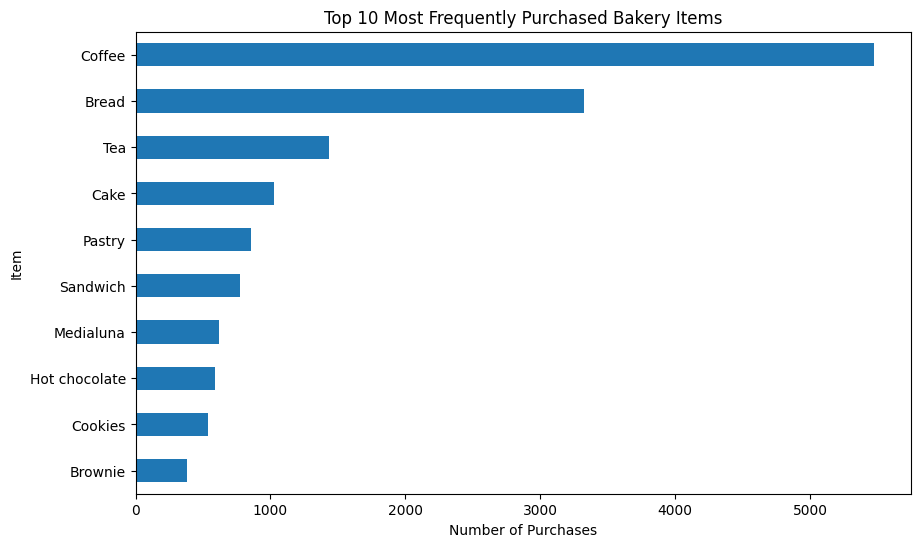

In [34]:
plt.figure(figsize=(10, 6))

item_counts.sort_values().plot(kind="barh")

plt.title("Top 10 Most Frequently Purchased Bakery Items")
plt.xlabel("Number of Purchases")
plt.ylabel("Item")

plt.show()

## 4. Transaction Analysis

In [35]:
transaction_count = df_clean["Transaction"].nunique()

print("Number of transactions:", transaction_count)

Number of transactions: 9465


In [36]:
transaction_items = (
    df_clean
    .groupby("Transaction")["Item"]
    .apply(list)
)

transaction_items.head()

items = sorted(df_clean["Item"].unique())

co_occurrence = pd.DataFrame(
    0,
    index=items,
    columns=items
)

for transaction in transaction_items:
    unique_items = list(set(transaction))

    for item1 in unique_items:
        for item2 in unique_items:
            if item1 != item2:
                co_occurrence.loc[item1, item2] += 1

In [37]:
print(
    "Coffee + Tea transactions:",
    co_occurrence.loc["Coffee", "Tea"]
)

print(
    "Bread + Coffee transactions:",
    co_occurrence.loc["Bread", "Coffee"]
)

Coffee + Tea transactions: 472
Bread + Coffee transactions: 852


## 5. Most Frequently Purchased Product Pairs

In [38]:
# Convert the co-occurrence matrix into a list of product pairs

pairs = []

for item1 in co_occurrence.index:
    for item2 in co_occurrence.columns:
        if item1 < item2:
            count = co_occurrence.loc[item1, item2]

            if count > 0:
                pairs.append((item1, item2, count))

pair_counts = pd.DataFrame(
    pairs,
    columns=["Item 1", "Item 2", "Transactions"]
)

pair_counts = pair_counts.sort_values(
    "Transactions",
    ascending=False
)

pair_counts.head(10)

,Item 1,Item 2,Transactions
190,Bread,Coffee,852
305,Cake,Coffee,518
467,Coffee,Tea,472
454,Coffee,Pastry,450
459,Coffee,Sandwich,362
446,Coffee,Medialuna,333
439,Coffee,Hot chocolate,280
226,Bread,Pastry,276
419,Coffee,Cookies,267
239,Bread,Tea,266


## 6. Product Pair Visualization

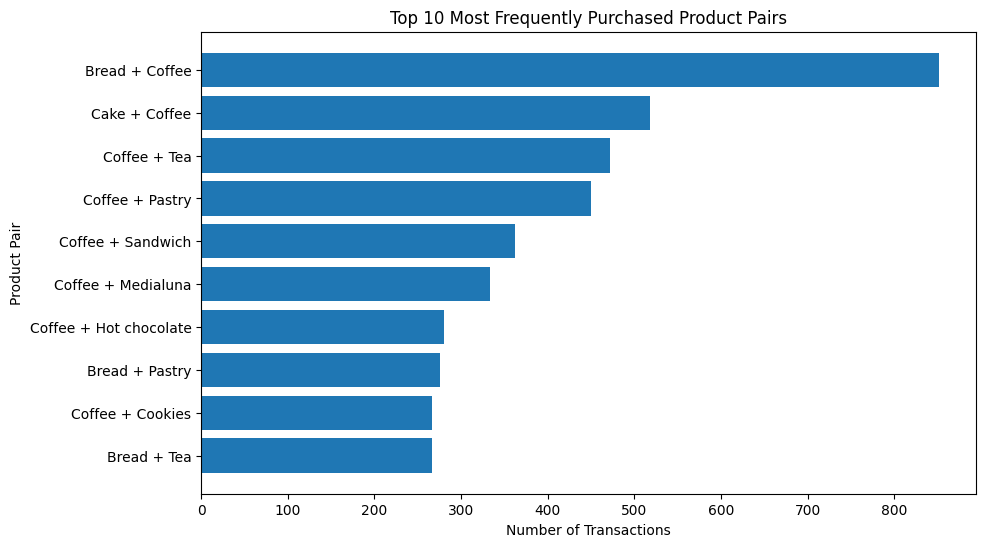

In [39]:
top_pairs = pair_counts.head(10).copy()

top_pairs["Pair"] = (
    top_pairs["Item 1"] + " + " + top_pairs["Item 2"]
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_pairs["Pair"][::-1],
    top_pairs["Transactions"][::-1]
)

plt.title("Top 10 Most Frequently Purchased Product Pairs")
plt.xlabel("Number of Transactions")
plt.ylabel("Product Pair")

plt.show()

## 7. Products Commonly Purchased with Coffee

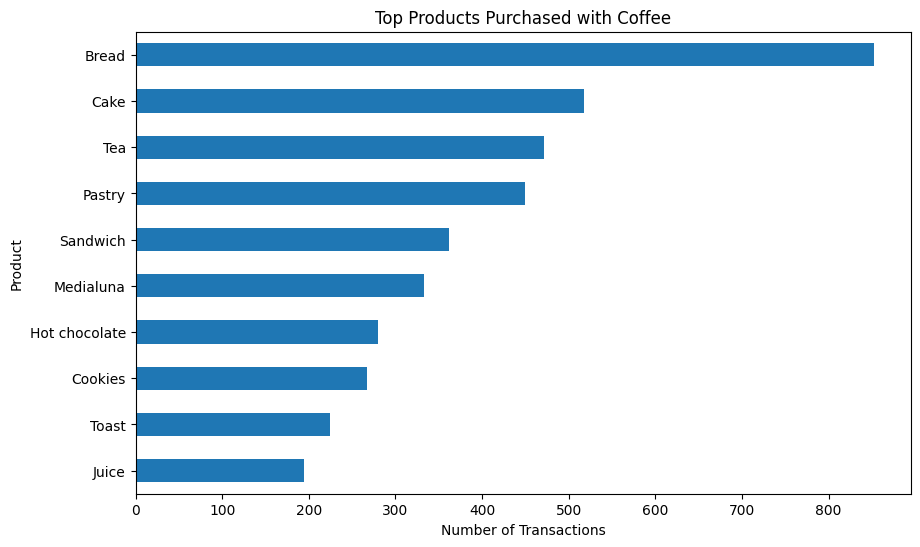

In [40]:
coffee_pairs = (
    co_occurrence["Coffee"]
    .drop("Coffee")
    .sort_values(ascending=False)
    .head(10)
)

coffee_pairs

plt.figure(figsize=(10, 6))

coffee_pairs.sort_values().plot(kind="barh")

plt.title("Top Products Purchased with Coffee")
plt.xlabel("Number of Transactions")
plt.ylabel("Product")

plt.show()

## Key Findings
- The dataset contained 21,293 transaction records, with 20,507 valid records remaining after cleaning.
- The dataset included 94 unique bakery products across 9,465 transactions.
- Coffee was the most frequently purchased item, with 5,471 purchases.
- Bread + Coffee was the most common product combination, appearing together in 852 transactions.
- Other frequent combinations included Cake + Coffee (518) and Coffee + Tea (472).

## Skills Demonstrated

* Python
* Pandas
* Data Cleaning
* Transaction Analysis
* Data Transformation
* Exploratory Data Analysis
* Data Visualization
* Product Co-occurrence Analysis
* Data Interpretation
